# Common analytical features
## Scaling
### z-score

$z=\frac{x-\mu}{\sigma}$

Example: income seems to be related to highest degree completed. It is unfair to compare people's income with people with different education attainment. We can compute income's z-score by education so we can compare them with their peers.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# read the data
nls97 = pd.read_csv("../05-data_cleaning/data/nls97.csv")

nls97

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
1,100139,Male,9,1983,12.0,Married,2.0,0.0,120000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
2,100284,Male,11,1984,7.0,Never-married,1.0,0.0,58000.0,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
3,100292,Male,4,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,NaN,NaN,NaN,NaN
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8979,999291,Female,4,1981,16.0,Married,NaN,NaN,35000.0,7 to 9 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
8980,999406,Male,7,1982,14.0,Never-married,NaN,NaN,116000.0,4 to 6 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
8981,999543,Female,8,1984,12.0,Divorced,2.0,0.0,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
8982,999698,Female,5,1983,12.0,Never-married,5.0,0.0,NaN,4 to 6 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled


In [15]:
nls97['highestdegree'].value_counts()

highestdegree
2. High School     3667
4. Bachelors       1673
1. GED             1146
0. None             953
3. Associates       737
5. Masters          603
7. Professional     120
6. PhD               54
Name: count, dtype: int64

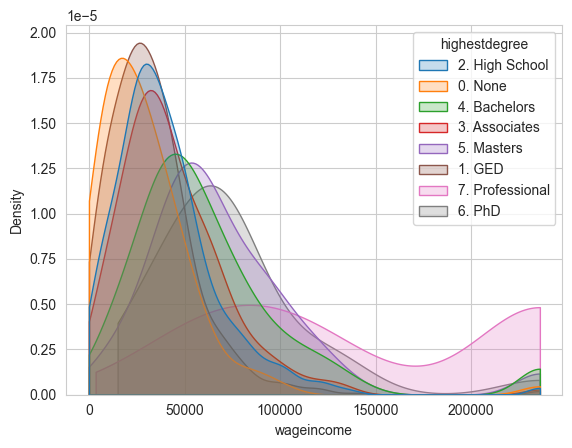

In [19]:
sns.kdeplot(data=nls97, x="wageincome", hue='highestdegree', fill=True, cut=0, common_norm=False)
plt.show()

In [11]:
mean_wage = nls97['wageincome'].mean()
std_wage = nls97['wageincome'].std()

nls97['wageincome_z_score'] = (nls97['wageincome'] - mean_wage) / std_wage
nls97['wageincome_z_score_by_education'] = nls97.groupby("highestdegree")['wageincome'].transform(lambda x: (x - x.mean()) / x.std())

nls97[['personid', 'highestdegree', 'wageincome','wageincome_z_score','wageincome_z_score_by_education']].head()

,personid,highestdegree,wageincome,wageincome_z_score,wageincome_z_score_by_education
0,100061,2. High School,12500.0,-0.909024,-0.954533
1,100139,2. High School,120000.0,1.733701,2.696763
2,100284,0. None,58000.0,0.209525,0.916007
3,100292,4. Bachelors,NaN,NaN,NaN
4,100583,2. High School,30000.0,-0.478813,-0.360136


<Axes: xlabel='wageincome_z_score_by_education', ylabel='Density'>

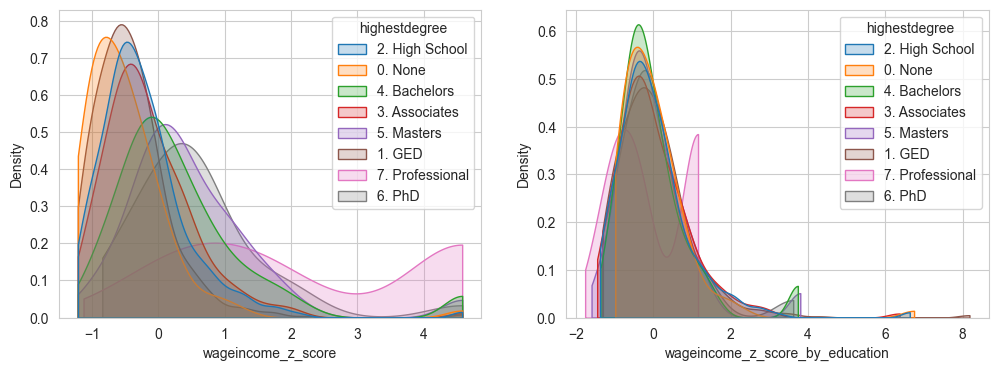

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.kdeplot(data=nls97, x="wageincome_z_score", hue='highestdegree', fill=True, cut=0, common_norm=False, ax=axes[0])

sns.kdeplot(data=nls97, x="wageincome_z_score_by_education", hue='highestdegree', fill=True, cut=0, common_norm=False, ax=axes[1])


### Interpret z-score

In [30]:
nls97['high_wages'] = (nls97['wageincome_z_score'] > 3).astype(int)
nls97['high_wages_by_education'] = (nls97['wageincome_z_score_by_education'] > 3).astype(int)

In [31]:
nls97[(nls97['high_wages']==1) & (nls97['high_wages_by_education']==0)][['personid','gender','highestdegree','wageincome']]

,personid,gender,highestdegree,wageincome
343,131858,Male,7. Professional,235884.0
651,164058,Male,7. Professional,235884.0
767,175442,Male,7. Professional,235884.0
1574,253373,Male,7. Professional,235884.0
1676,264469,Male,7. Professional,235884.0
1714,268217,Male,7. Professional,235884.0
2122,308385,Female,7. Professional,235884.0
2143,310473,Male,7. Professional,235884.0
2278,325632,Female,7. Professional,235884.0
2894,387118,Male,7. Professional,235884.0


### Min-max scaling


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../07-Data_visualization/data/stony_brook_daily_temperature_2025.csv")

# Convert Celsius → Fahrenheit
df["temp_F"] = df["average_temperature"] * 9/5 + 32
df['date'] = pd.to_datetime('2025-' + df['month'].astype(str) + '-' + df['day'].astype(str))

df

,month,day,average_temperature,temp_F,date
0,1,1,7.5,45.50,2025-01-01
1,1,2,3.3,37.94,2025-01-02
2,1,3,0.6,33.08,2025-01-03
3,1,4,-1.5,29.30,2025-01-04
4,1,5,-2.3,27.86,2025-01-05
...,...,...,...,...,...
360,12,27,-3.3,26.06,2025-12-27
361,12,28,-2.8,26.96,2025-12-28
362,12,29,5.8,42.44,2025-12-29
363,12,30,-1.2,29.84,2025-12-30


In [3]:
min_val = df["temp_F"].min()
max_val = df["temp_F"].max()

df["temp_scaled"] = (df["temp_F"] - min_val) / (max_val - min_val)

df[['date','temp_F','temp_scaled']]

,date,temp_F,temp_scaled
0,2025-01-01,45.50,0.4200
1,2025-01-02,37.94,0.3150
2,2025-01-03,33.08,0.2475
3,2025-01-04,29.30,0.1950
4,2025-01-05,27.86,0.1750
...,...,...,...
360,2025-12-27,26.06,0.1500
361,2025-12-28,26.96,0.1625
362,2025-12-29,42.44,0.3775
363,2025-12-30,29.84,0.2025


In [7]:
# this is equivalent to:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

df["temp_scaled"] = min_max_scaler.fit_transform(df[["temp_F"]])

df[['date','temp_F','temp_scaled']]

,date,temp_F,temp_scaled
0,2025-01-01,45.50,0.4200
1,2025-01-02,37.94,0.3150
2,2025-01-03,33.08,0.2475
3,2025-01-04,29.30,0.1950
4,2025-01-05,27.86,0.1750
...,...,...,...
360,2025-12-27,26.06,0.1500
361,2025-12-28,26.96,0.1625
362,2025-12-29,42.44,0.3775
363,2025-12-30,29.84,0.2025


<Axes: xlabel='temp_scaled', ylabel='Density'>

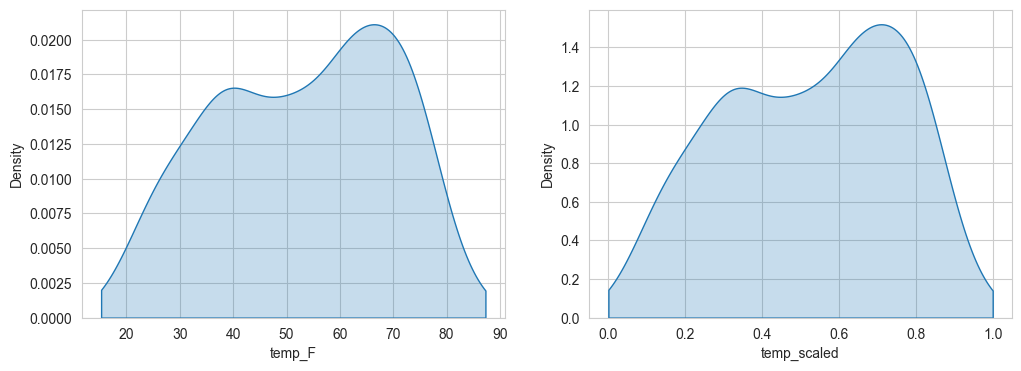

In [43]:
# observe the following distributions. Their shape look the same, but the scales (x-axis) are different.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.kdeplot(data=df, x="temp_F", fill=True, clip=(min_val, max_val), ax=axes[0])

sns.kdeplot(data=df, x="temp_scaled", fill=True, clip=(0, 1), ax=axes[1])


Why It’s Useful?
Add another variable (different scale), and compare before vs after

In [45]:
df["humidity"] = np.random.uniform(20, 100, df.shape[0])

# Scale humidity too
df["humidity_scaled"] = (
    (df["humidity"] - df["humidity"].min()) /
    (df["humidity"].max() - df["humidity"].min())
)

df[['date','temp_F','humidity','temp_scaled','humidity_scaled']]

,date,temp_F,humidity,temp_scaled,humidity_scaled
0,2025-01-01,45.50,53.864857,0.4200,0.423280
1,2025-01-02,37.94,21.989383,0.3150,0.024756
2,2025-01-03,33.08,96.664925,0.2475,0.958389
3,2025-01-04,29.30,32.539475,0.1950,0.156659
4,2025-01-05,27.86,61.885183,0.1750,0.523554
...,...,...,...,...,...
360,2025-12-27,26.06,51.075016,0.1500,0.388400
361,2025-12-28,26.96,43.658770,0.1625,0.295678
362,2025-12-29,42.44,74.497800,0.3775,0.681244
363,2025-12-30,29.84,86.646086,0.2025,0.833128


<Axes: xlabel='value', ylabel='Density'>

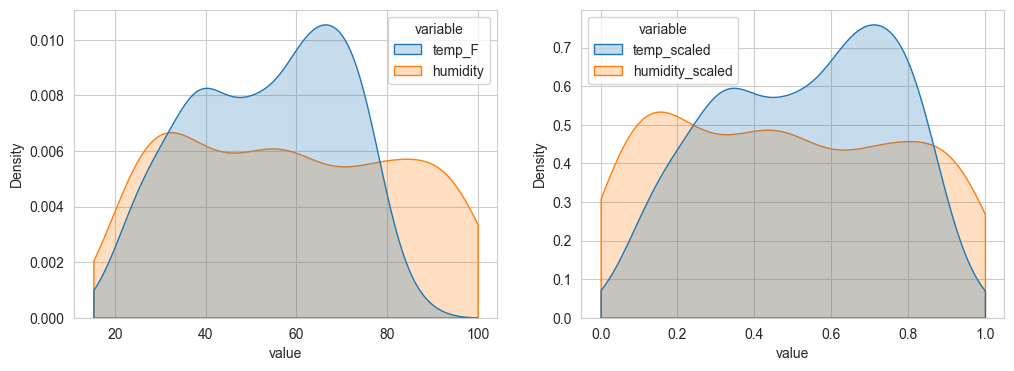

In [51]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.kdeplot(data=df.melt(id_vars='date', value_vars=['temp_F', 'humidity']), x='value', hue='variable', fill=True, clip=(min([df['temp_F'].min(), df['humidity'].min()]), max([df['temp_F'].max(), df['humidity'].max()])), ax=axes[0])

sns.kdeplot(data=df.melt(id_vars='date', value_vars=['temp_scaled', 'humidity_scaled']), x='value', hue='variable', clip=(0, 1),fill=True, ax=axes[1])


## Concentration & Inequality
### HHI (Herfindahl-Hirschman Index)

HHI for AI Research Concentration by Country

$HHI = \sum_{i=0}^{n}{p_i}^2$, where $p_i$ represents the proportion of group $i$, and $n$ represents the total number of groups in the system (or environment).

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/ai_paper_per_county_data.csv")

df

,country,year,ai_paper_count
0,Afghanistan,2017,1
1,Afghanistan,2018,1
2,Albania,2010,1
3,Albania,2011,1
4,Albania,2012,2
...,...,...,...
2890,Zimbabwe,2016,3
2891,Zimbabwe,2017,8
2892,Zimbabwe,2018,7
2893,Zimbabwe,2019,5


#### Let's compute the HHI for the year of 2019



In [16]:
df_2019 = df[df['year'] == 2019].copy()

df_2019

,country,year,ai_paper_count
10,Albania,2019,4
32,Algeria,2019,260
62,Argentina,2019,142
72,Armenia,2019,9
107,Australia,2019,2069
...,...,...,...
2838,Venezuela,2019,20
2857,Vietnam,2019,486
2867,Yemen,2019,21
2882,Zambia,2019,15


There are 162 countries with 77,065 AI publications in 2019 worldwide.


<Axes: xlabel='ai_paper_count', ylabel='Count'>

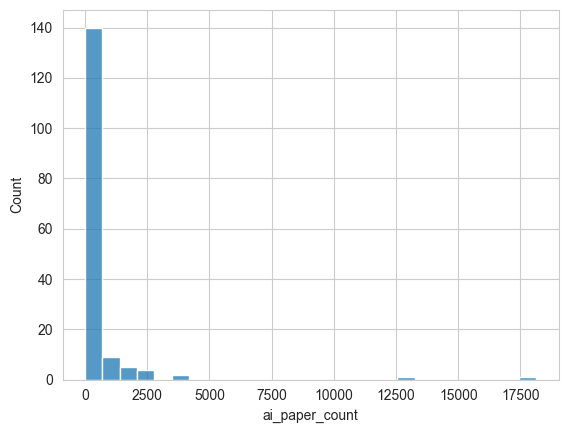

In [23]:
print(f"There are {df_2019.shape[0]} countries with {df_2019['ai_paper_count'].sum():,} AI publications in 2019 worldwide.")

sns.histplot(data=df_2019, x='ai_paper_count')

In [24]:
# Compute percentage of each country's AI papers
total_pub_count = df_2019['ai_paper_count'].sum()

df_2019['pct'] = df_2019['ai_paper_count'] / total_pub_count

df_2019

,country,year,ai_paper_count,pct
10,Albania,2019,4,0.000052
32,Algeria,2019,260,0.003374
62,Argentina,2019,142,0.001843
72,Armenia,2019,9,0.000117
107,Australia,2019,2069,0.026847
...,...,...,...,...
2838,Venezuela,2019,20,0.000260
2857,Vietnam,2019,486,0.006306
2867,Yemen,2019,21,0.000272
2882,Zambia,2019,15,0.000195


In [25]:
# compute HHI

hhi_2019 = (df_2019['pct']**2).sum()

print(f"The HHI of AI paper by country in 2019 is {hhi_2019:.2f}")

The HHI of AI paper by country in 2019 is 0.10


#### Compare the country-wise concentration of AI publication in 2000, 2005, 2010, 2015, 2020

In [28]:
for year in [2000, 2005, 2010, 2015, 2020]:
    total_pub_count = df[df['year'] == year]['ai_paper_count'].sum()
    hhi = ((df[df['year']==year]['ai_paper_count'] / total_pub_count)**2).sum()
    print(f"{year}: {hhi=:.3f}")

print("As we can see, 2020 has a higher concentration than 2000, meaning less diversity")

2000: hhi=0.089
2005: hhi=0.074
2010: hhi=0.065
2015: hhi=0.071
2020: hhi=0.102


#### Compute HHI across the years using `groupby`

In [30]:
hhi_df = df.groupby("year").agg(
    hhi=('ai_paper_count', lambda x: ((x/x.sum())**2).sum()))

hhi_df

,hhi
year,
1966,1.000000
1967,1.000000
1968,0.500000
1970,1.000000
1971,0.625000
1972,0.500000
1973,0.386667
1974,0.623457
1975,0.605536


#### Plotting the time series of HHI

It shows the trend of concentration of AI research worldwide:
- Before 2010, the concentration was reducing, which means more countries are joining AI research
- After 2010, the concentration increased, meaning that AI research is increasingly concentrated in a few counties.

<Axes: xlabel='year', ylabel='hhi'>

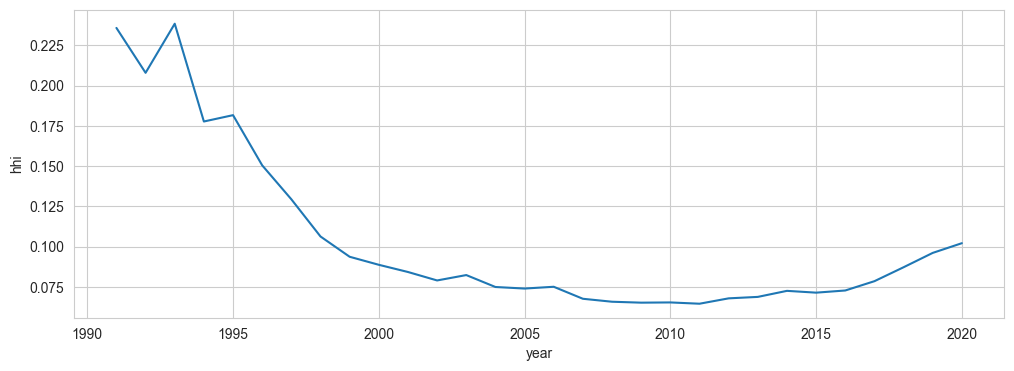

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

sns.lineplot(data=hhi_df.query("year > 1990"), x='year', y='hhi', ax=ax)

### Gini's Diversity Index

$1-HHI = 1- \sum_{i=0}^{n}{p_i}^2$


In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/ai_paper_per_county_data.csv")

df

,country,year,ai_paper_count
0,Afghanistan,2017,1
1,Afghanistan,2018,1
2,Albania,2010,1
3,Albania,2011,1
4,Albania,2012,2
...,...,...,...
2890,Zimbabwe,2016,3
2891,Zimbabwe,2017,8
2892,Zimbabwe,2018,7
2893,Zimbabwe,2019,5


In [35]:
# Compute Gini's diversity index

yearly_diversity = df.groupby('year', as_index=False).agg(
    country_count=('country', 'count'),
    diversity=("ai_paper_count", lambda x: 1-((x/x.sum())**2).sum())
)

yearly_diversity

,year,country_count,diversity
0,1966,1,0.000000
1,1967,1,0.000000
2,1968,2,0.500000
3,1970,1,0.000000
4,1971,2,0.375000
5,1972,2,0.500000
6,1973,7,0.613333
7,1974,4,0.376543
8,1975,4,0.394464
9,1976,5,0.388430


In [ ]:
# Plot the time series of the diversity and the number of countries

Text(0.5, 0, "Gini's Diversity Index")

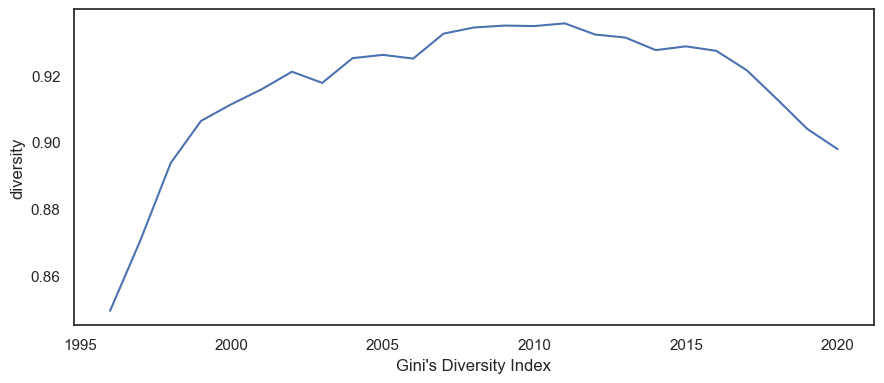

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4), tight_layout=True)

select_year = 1995

sns.lineplot(data=yearly_diversity.query("year > @select_year"), x='year', y='diversity', ax=ax)
ax.set_xlabel("Gini's Diversity Index")


#### Inspect the country composition of AI publications

In [72]:
# choose only the top 10 countries to plot, and set others as other
top_ten_countries = df.groupby('country', as_index=False)['ai_paper_count'].sum().nlargest(n=10, columns='ai_paper_count')['country'].to_list()

df['country_adj'] = df['country'].apply(lambda x: x if x in top_ten_countries else "others")


df_adjust_country = df.groupby(["country_adj",'year'], as_index=False)['ai_paper_count'].sum().rename(columns={'country_adj':'country'})

df_adjust_country['pct'] = df_adjust_country.groupby("year")['ai_paper_count'].transform(lambda x: x/x.sum())

# cast country column to categorical to maintain orders
df_adjust_country['country'] = df_adjust_country['country'].astype(pd.CategoricalDtype(
    categories=top_ten_countries + ['others'], ordered=True
))

df_adjust_country

,country,year,ai_paper_count,pct
0,Canada,1968,1,0.500000
1,Canada,1974,1,0.055556
2,Canada,1975,1,0.058824
3,Canada,1977,1,0.066667
4,Canada,1984,3,0.100000
...,...,...,...,...
401,others,2016,10427,0.362439
402,others,2017,12601,0.353514
403,others,2018,17824,0.340940
404,others,2019,25545,0.331473


In [74]:
area_plot_df = pd.pivot_table(data=df_adjust_country, index='year', columns='country', values='pct', observed=True).fillna(0)
area_plot_df

country,Peoples R China,USA,UK,India,Iran,Germany,Canada,Spain,South Korea,Italy,others
year,,,,,,,,,,,
1966,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1967,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1968,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
1970,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1971,0.000000,0.250000,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1972,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1973,0.000000,0.600000,0.066667,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667,0.200000
1974,0.000000,0.777778,0.111111,0.000000,0.000000,0.000000,0.055556,0.000000,0.000000,0.000000,0.055556
1975,0.000000,0.764706,0.000000,0.000000,0.000000,0.000000,0.058824,0.000000,0.000000,0.000000,0.176471


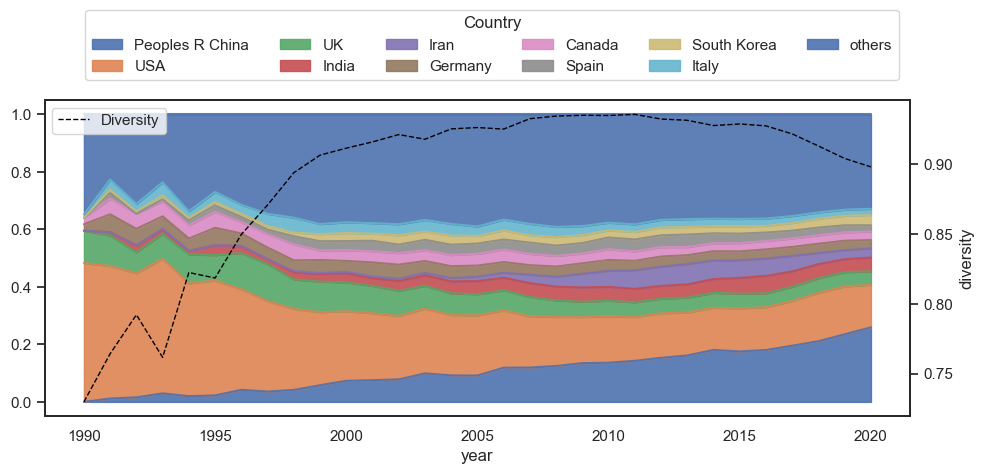

In [97]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)
sns.set_style("white")
start_year = 1990

# plot area plot
area_plot_df.query("year >= @start_year").plot(kind='area', ax=ax, alpha=0.9)

# plot diversity index
ax_twin = ax.twinx()
sns.lineplot(data=yearly_diversity.query("year >= @start_year"), x='year', y='diversity', ax=ax_twin,
             color="black", lw=1, ls="--", label='Diversity')

handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(handles, labels, loc='upper center', ncol=6, bbox_to_anchor=(.5,1.2),frameon=True,title='Country')


### Shannon Entropy
$H = -\sum{p_i}\log{p_i}$

Normalized Shannon entropy

$H_{norm} = \frac{-\sum_{i}^{n}{p_i}\log{p_i}}{\log{n}}$

Let's compute both country-wise Gini's diversity index and Shannon entropy (and normalized entropy) for yearly AI publications.

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/ai_paper_per_county_data.csv")

df

,country,year,ai_paper_count
0,Afghanistan,2017,1
1,Afghanistan,2018,1
2,Albania,2010,1
3,Albania,2011,1
4,Albania,2012,2
...,...,...,...
2890,Zimbabwe,2016,3
2891,Zimbabwe,2017,8
2892,Zimbabwe,2018,7
2893,Zimbabwe,2019,5


In [113]:
diversity_df = df.groupby("year", as_index=False).agg(
    country_count=('country', 'count'),
    gini_diversity=("ai_paper_count", lambda x: 1-((x/x.sum())**2).sum()),
    shannon_entropy=("ai_paper_count", lambda x: -((x/x.sum())*(np.log2(x/x.sum()))).sum()),
    normalized_shannon_entropy=("ai_paper_count", lambda x: -((x/x.sum())*(np.log2(x/x.sum()))).sum()/np.log2(len(x)+1))
)

diversity_df

,year,country_count,gini_diversity,shannon_entropy,normalized_shannon_entropy
0,1966,1,0.000000,-0.000000,-0.000000
1,1967,1,0.000000,-0.000000,-0.000000
2,1968,2,0.500000,1.000000,0.630930
3,1970,1,0.000000,-0.000000,-0.000000
4,1971,2,0.375000,0.811278,0.511860
5,1972,2,0.500000,1.000000,0.630930
6,1973,7,0.613333,2.004936,0.668312
7,1974,4,0.376543,1.097538,0.472684
8,1975,4,0.394464,1.140068,0.491000
9,1976,5,0.388430,1.210029,0.468103


<Axes: xlabel='year', ylabel='value'>

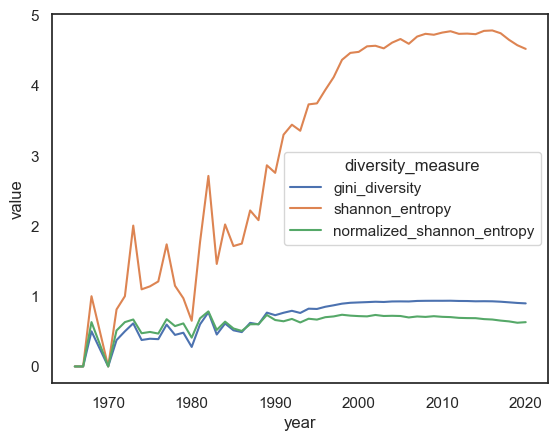

In [114]:
sns.lineplot(data=diversity_df.melt(id_vars='year', value_vars=['gini_diversity', 'shannon_entropy', 'normalized_shannon_entropy'], var_name=(var_name:='diversity_measure')), hue=var_name, x='year', y='value')

In [116]:
# Check whether Gini index and Shannon entropy correlate

diversity_df[['gini_diversity', 'shannon_entropy', 'normalized_shannon_entropy']].corr()

,gini_diversity,shannon_entropy,normalized_shannon_entropy
gini_diversity,1.000000,0.960619,0.874015
shannon_entropy,0.960619,1.000000,0.710518
normalized_shannon_entropy,0.874015,0.710518,1.000000


<Axes: xlabel='gini_diversity', ylabel='shannon_entropy'>

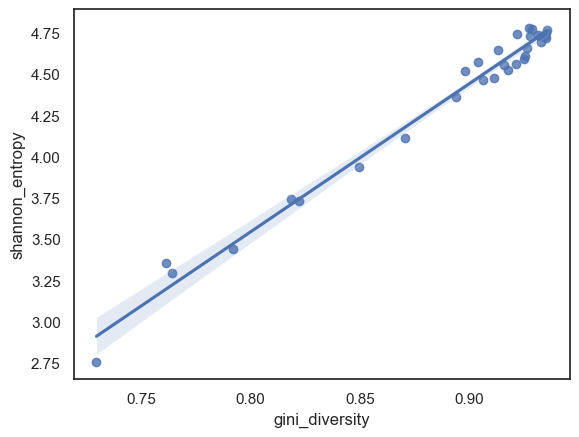

In [119]:
sns.regplot(data=diversity_df.query("year >= 1990"), x='gini_diversity', y='shannon_entropy')

## Growth rate
We wanted to look at the growth rate of (1) AI papers and (2) countries where AI research is conducted

In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/ai_paper_per_county_data.csv")

df

,country,year,ai_paper_count
0,Afghanistan,2017,1
1,Afghanistan,2018,1
2,Albania,2010,1
3,Albania,2011,1
4,Albania,2012,2
...,...,...,...
2890,Zimbabwe,2016,3
2891,Zimbabwe,2017,8
2892,Zimbabwe,2018,7
2893,Zimbabwe,2019,5


In [125]:
yearly_df = df.groupby("year", as_index=False).agg(
    country_count=('country', 'count'),
    paper_count=("ai_paper_count", "sum")).sort_values(by='year', ascending=True)

yearly_df

,year,country_count,paper_count
0,1966,1,1
1,1967,1,1
2,1968,2,2
3,1970,1,1
4,1971,2,4
5,1972,2,2
6,1973,7,15
7,1974,4,18
8,1975,4,17
9,1976,5,22


In [138]:
# compute growth rate

yearly_df['country_gr'] = yearly_df['country_count'].pct_change()
yearly_df['paper_gr'] = yearly_df['paper_count'].pct_change()
yearly_df['paper_growth'] = yearly_df['paper_count'].diff()

yearly_df

,year,country_count,paper_count,country_gr,paper_gr,paper_growth
0,1966,1,1,NaN,NaN,NaN
1,1967,1,1,0.000000,0.000000,0.0
2,1968,2,2,1.000000,1.000000,1.0
3,1970,1,1,-0.500000,-0.500000,-1.0
4,1971,2,4,1.000000,3.000000,3.0
5,1972,2,2,0.000000,-0.500000,-2.0
6,1973,7,15,2.500000,6.500000,13.0
7,1974,4,18,-0.428571,0.200000,3.0
8,1975,4,17,0.000000,-0.055556,-1.0
9,1976,5,22,0.250000,0.294118,5.0


<Axes: xlabel='year', ylabel='paper_gr'>

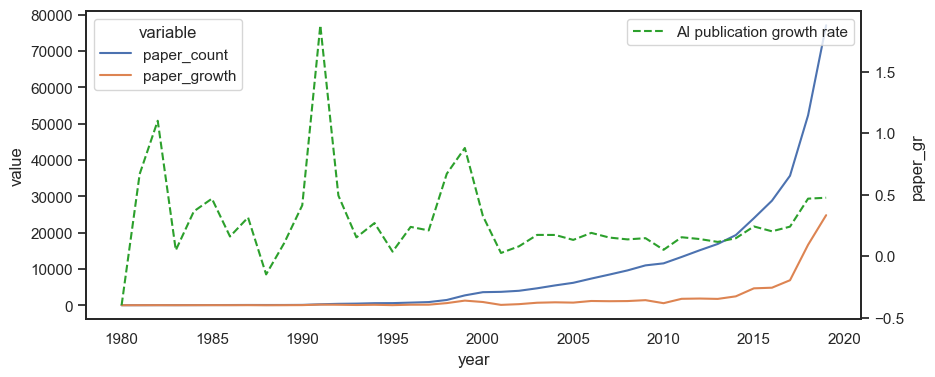

In [140]:
# Inspect the growth rate
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
start_year, end_year = 1980, 2019

sns.lineplot(data=yearly_df.query("@start_year <= year <= @end_year").melt(id_vars="year", value_vars=['paper_count', 'paper_growth']), x='year', y='value', hue='variable', ax=ax)

ax_twin = ax.twinx()
sns.lineplot(data=yearly_df.query("@start_year <= year <= @end_year"), x='year', y='paper_gr', ax=ax_twin, color="tab:green", ls="--",
             label='AI publication growth rate')

## Similarity measures
### Jaccard similarity
Example, let's compute Jaccard similarity between movies

For example, the genre of The Shawshank Redemption is drama, and genre of The Godfather is drama and crime. Therefore, the genre similarity between the two movies is 0.5.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")
df["genre_list"] = df["genre"].str.split(",")
df["genre_set"] = df["genre_list"].apply(set)

df

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers,genre_list,genre_set
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000,28884504,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont",[Drama],{Drama}
1,2,The Godfather,1972,9.2,"Crime,Drama",R,2h 55m,An offer you can't refuse.,6000000,250341816,"Marlon Brando,Al Pacino,James Caan,Diane Keato...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola","[Crime, Drama]","{Drama, Crime}"
2,3,The Dark Knight,2008,9.0,"Action,Crime,Drama",PG-13,2h 32m,Why So Serious?,185000000,1006234167,"Christian Bale,Heath Ledger,Aaron Eckhart,Mich...",Christopher Nolan,"Jonathan Nolan,Christopher Nolan,David S. Goyer","[Action, Crime, Drama]","{Drama, Action, Crime}"
3,4,The Godfather Part II,1974,9.0,"Crime,Drama",R,3h 22m,All the power on earth can't change destiny.,13000000,47961919,"Al Pacino,Robert De Niro,Robert Duvall,Diane K...",Francis Ford Coppola,"Francis Ford Coppola,Mario Puzo","[Crime, Drama]","{Drama, Crime}"
4,5,12 Angry Men,1957,9.0,"Crime,Drama",Approved,1h 36m,Life Is In Their Hands -- Death Is On Their Mi...,350000,955,"Henry Fonda,Lee J. Cobb,Martin Balsam,John Fie...",Sidney Lumet,Reginald Rose,"[Crime, Drama]","{Drama, Crime}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,246,The Help,2011,8.1,Drama,PG-13,2h 26m,Change begins with a whisper.,25000000,216639112,"Viola Davis,Emma Stone,Octavia Spencer,Bryce D...",Tate Taylor,"Tate Taylor,Kathryn Stockett",[Drama],{Drama}
246,247,Dersu Uzala,1975,8.2,"Adventure,Biography,Drama",G,2h 22m,There is man and beast at nature's mercy. Ther...,4000000,14480,"Maksim Munzuk,Yuriy Solomin,Mikhail Bychkov,Vl...",Akira Kurosawa,"Akira Kurosawa,Yuriy Nagibin,Vladimir Arsenev","[Adventure, Biography, Drama]","{Drama, Biography, Adventure}"
247,248,Aladdin,1992,8.0,"Animation,Adventure,Comedy",G,1h 30m,Wish granted! (DVD re-release),Not Available,Not Available,"Scott Weinger,Robin Williams,Linda Larkin,Jona...","Ron Clements,John Musker","Ron Clements,John Musker,Ted Elliott","[Animation, Adventure, Comedy]","{Comedy, Animation, Adventure}"
248,249,Gandhi,1982,8.0,"Biography,Drama,History",PG,3h 11m,His Triumph Changed The World Forever.,22000000,52767889,"Ben Kingsley,John Gielgud,Rohini Hattangadi,Ro...",Richard Attenborough,John Briley,"[Biography, Drama, History]","{History, Drama, Biography}"


In [2]:
def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

sim = jaccard(df["genre_set"].iloc[0], df["genre_set"].iloc[1])

print("Jaccard similarity:", sim)

Jaccard similarity: 0.5


In [3]:
movies = df["name"].tolist()

jaccard_matrix_genre = pd.DataFrame(index=movies, columns=movies)

for i in range(len(df)):
    for j in range(len(df)):
        jaccard_matrix_genre.iloc[i, j] = jaccard(
            df.loc[i, "genre_set"],
            df.loc[j, "genre_set"]
        )

jaccard_matrix_genre

,The Shawshank Redemption,The Godfather,The Dark Knight,The Godfather Part II,12 Angry Men,Schindler's List,The Lord of the Rings: The Return of the King,Pulp Fiction,The Lord of the Rings: The Fellowship of the Ring,"The Good, the Bad and the Ugly",...,The Sound of Music,It Happened One Night,Persona,Life of Brian,The Iron Giant,The Help,Dersu Uzala,Aladdin,Gandhi,Dances with Wolves
The Shawshank Redemption,1.0,0.5,0.333333,0.5,0.5,0.333333,0.333333,0.5,0.333333,0.0,...,0.333333,0.0,0.5,0.0,0.0,1.0,0.333333,0.0,0.333333,0.333333
The Godfather,0.5,1.0,0.666667,1.0,1.0,0.25,0.25,1.0,0.25,0.0,...,0.25,0.0,0.333333,0.0,0.0,0.5,0.25,0.0,0.25,0.25
The Dark Knight,0.333333,0.666667,1.0,0.666667,0.666667,0.2,0.5,0.666667,0.5,0.0,...,0.2,0.0,0.25,0.0,0.2,0.333333,0.2,0.0,0.2,0.2
The Godfather Part II,0.5,1.0,0.666667,1.0,1.0,0.25,0.25,1.0,0.25,0.0,...,0.25,0.0,0.333333,0.0,0.0,0.5,0.25,0.0,0.25,0.25
12 Angry Men,0.5,1.0,0.666667,1.0,1.0,0.25,0.25,1.0,0.25,0.0,...,0.25,0.0,0.333333,0.0,0.0,0.5,0.25,0.0,0.25,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
The Help,1.0,0.5,0.333333,0.5,0.5,0.333333,0.333333,0.5,0.333333,0.0,...,0.333333,0.0,0.5,0.0,0.0,1.0,0.333333,0.0,0.333333,0.333333
Dersu Uzala,0.333333,0.25,0.2,0.25,0.25,0.5,0.5,0.25,0.5,0.25,...,0.5,0.0,0.25,0.0,0.2,0.333333,1.0,0.2,0.5,0.5
Aladdin,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.25,...,0.0,0.25,0.0,0.333333,0.5,0.0,0.2,1.0,0.0,0.2
Gandhi,0.333333,0.25,0.2,0.25,0.25,1.0,0.2,0.25,0.2,0.0,...,0.5,0.0,0.25,0.0,0.0,0.333333,0.5,0.0,1.0,0.2


In [4]:
# Compute three similarity measures of genre, casts, and directors
from tqdm import tqdm

similarity_dfs = {}

for col in tqdm(['genre', "casts", "directors", "writers"]):
    df[f"{col}_list"] = df[col].str.split(",")
    df[f"{col}_set"] = df[f"{col}_list"].apply(set)

    movies = df["name"].tolist()

    jaccard_matrix = pd.DataFrame(index=movies, columns=movies)

    for i in range(len(df)):
        for j in range(len(df)):
            jaccard_matrix.iloc[i, j] = jaccard(
                df.loc[i, f"{col}_set"],
                df.loc[j, f"{col}_set"]
            )

    similarity_dfs[col] = jaccard_matrix
    del jaccard_matrix

100%|██████████| 4/4 [00:03<00:00,  1.23it/s]


In [5]:
from functools import reduce

weights = {
    "genre": 0.4,
    "casts": 0.3,
    "directors": 0.2,
    "writers": 0.1
}

final_similarity = reduce(lambda x, y: x + y,
    [value * similarity_dfs[key] for key,value in weights.items()])

final_similarity

,The Shawshank Redemption,The Godfather,The Dark Knight,The Godfather Part II,12 Angry Men,Schindler's List,The Lord of the Rings: The Return of the King,Pulp Fiction,The Lord of the Rings: The Fellowship of the Ring,"The Good, the Bad and the Ugly",...,The Sound of Music,It Happened One Night,Persona,Life of Brian,The Iron Giant,The Help,Dersu Uzala,Aladdin,Gandhi,Dances with Wolves
The Shawshank Redemption,1.0,0.2,0.141905,0.2,0.2,0.133333,0.133333,0.2,0.133333,0.0,...,0.133333,0.0,0.2,0.0,0.0,0.4,0.133333,0.0,0.133333,0.133333
The Godfather,0.2,1.0,0.266667,0.76,0.408571,0.1,0.1,0.4,0.1,0.0,...,0.1,0.0,0.133333,0.0,0.0,0.2,0.1,0.0,0.1,0.1
The Dark Knight,0.141905,0.266667,1.0,0.266667,0.266667,0.08,0.2,0.266667,0.2,0.0,...,0.08,0.0,0.1,0.0,0.08,0.133333,0.08,0.0,0.08,0.08
The Godfather Part II,0.2,0.76,0.266667,1.0,0.4,0.1,0.1,0.4,0.1,0.0,...,0.1,0.0,0.133333,0.0,0.0,0.2,0.1,0.0,0.1,0.1
12 Angry Men,0.2,0.408571,0.266667,0.4,1.0,0.1,0.1,0.4,0.1,0.0,...,0.1,0.0,0.133333,0.0,0.0,0.2,0.1,0.0,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
The Help,0.4,0.2,0.133333,0.2,0.2,0.133333,0.133333,0.2,0.133333,0.0,...,0.133333,0.0,0.2,0.0,0.0,1.0,0.133333,0.0,0.133333,0.133333
Dersu Uzala,0.133333,0.1,0.08,0.1,0.1,0.2,0.2,0.1,0.2,0.1,...,0.2,0.0,0.1,0.0,0.08,0.133333,1.0,0.08,0.2,0.2
Aladdin,0.0,0.0,0.0,0.0,0.0,0.0,0.08,0.0,0.08,0.1,...,0.0,0.1,0.0,0.133333,0.217647,0.0,0.08,1.0,0.0,0.08
Gandhi,0.133333,0.1,0.08,0.1,0.1,0.408571,0.08,0.1,0.08,0.0,...,0.2,0.0,0.1,0.0,0.0,0.133333,0.2,0.0,1.0,0.08


In [6]:
# This is equivalent to:

final_similarity = (
    weights["genre"] * similarity_dfs['genre'] +
    weights["casts"] * similarity_dfs['casts'] +
    weights["directors"] * similarity_dfs['directors'] +
    weights["writers"] * similarity_dfs['writers']
)

final_similarity

,The Shawshank Redemption,The Godfather,The Dark Knight,The Godfather Part II,12 Angry Men,Schindler's List,The Lord of the Rings: The Return of the King,Pulp Fiction,The Lord of the Rings: The Fellowship of the Ring,"The Good, the Bad and the Ugly",...,The Sound of Music,It Happened One Night,Persona,Life of Brian,The Iron Giant,The Help,Dersu Uzala,Aladdin,Gandhi,Dances with Wolves
The Shawshank Redemption,1.0,0.2,0.141905,0.2,0.2,0.133333,0.133333,0.2,0.133333,0.0,...,0.133333,0.0,0.2,0.0,0.0,0.4,0.133333,0.0,0.133333,0.133333
The Godfather,0.2,1.0,0.266667,0.76,0.408571,0.1,0.1,0.4,0.1,0.0,...,0.1,0.0,0.133333,0.0,0.0,0.2,0.1,0.0,0.1,0.1
The Dark Knight,0.141905,0.266667,1.0,0.266667,0.266667,0.08,0.2,0.266667,0.2,0.0,...,0.08,0.0,0.1,0.0,0.08,0.133333,0.08,0.0,0.08,0.08
The Godfather Part II,0.2,0.76,0.266667,1.0,0.4,0.1,0.1,0.4,0.1,0.0,...,0.1,0.0,0.133333,0.0,0.0,0.2,0.1,0.0,0.1,0.1
12 Angry Men,0.2,0.408571,0.266667,0.4,1.0,0.1,0.1,0.4,0.1,0.0,...,0.1,0.0,0.133333,0.0,0.0,0.2,0.1,0.0,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
The Help,0.4,0.2,0.133333,0.2,0.2,0.133333,0.133333,0.2,0.133333,0.0,...,0.133333,0.0,0.2,0.0,0.0,1.0,0.133333,0.0,0.133333,0.133333
Dersu Uzala,0.133333,0.1,0.08,0.1,0.1,0.2,0.2,0.1,0.2,0.1,...,0.2,0.0,0.1,0.0,0.08,0.133333,1.0,0.08,0.2,0.2
Aladdin,0.0,0.0,0.0,0.0,0.0,0.0,0.08,0.0,0.08,0.1,...,0.0,0.1,0.0,0.133333,0.217647,0.0,0.08,1.0,0.0,0.08
Gandhi,0.133333,0.1,0.08,0.1,0.1,0.408571,0.08,0.1,0.08,0.0,...,0.2,0.0,0.1,0.0,0.0,0.133333,0.2,0.0,1.0,0.08


#### Practical exercise
With the similarity matrix, we can write a simple recommendation system for movies.

In [11]:
def recommend_movies(movie_name: str, similarity_df: pd.DataFrame, top_n=3):
    similarities = similarity_df[movie_name].sort_values(ascending=False)
    recommendations = similarities.iloc[1:top_n+1] # Remove itself
    return recommendations

In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output

movie_dropdown = widgets.Dropdown(options=df["name"].tolist(), description="Movie:")

recommend_button = widgets.Button(description="Recommend", button_style="primary")

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()

        selected_movie = movie_dropdown.value
        recs = recommend_movies(selected_movie, final_similarity)

        print(f"\nTop recommendations for '{selected_movie}':\n")
        for i, (movie, score) in enumerate(recs.items(), 1):
            print(f"{i}. {movie} (similarity: {score:.2f})")

recommend_button.on_click(on_button_click)
display(movie_dropdown, recommend_button, output)

Dropdown(description='Movie:', options=('The Shawshank Redemption', 'The Godfather', 'The Dark Knight', 'The G…

Button(button_style='primary', description='Recommend', style=ButtonStyle())

Output()